In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import obspy
from obspy.core import read, UTCDateTime, Stream
from obspy.clients.fdsn.client import Client
from obspy.geodetics import gps2dist_azimuth
from obspy.signal.cross_correlation import correlate, xcorr_max
import obspy.signal.filter as filter
from io_scripts import gmap2inv
import cartopy


### Parameters

In [4]:
starttime_mainshock   = UTCDateTime("2025-03-28T06:27:30")
endtime_mainshock     = UTCDateTime("2025-03-28T06:40:52") + 1000
eventtime_mainshock   = UTCDateTime("2025-03-28T06:20:52")

minperiod   = 15 # seconds
maxperiod   = 25 # seconds
minfreq     = 1/maxperiod
maxfreq     = 1/minperiod

hypocentre_lat = 21.996
hypocentre_lon = 95.926

client = Client("IRIS")

### Import stations

In [5]:
inventory = gmap2inv('/local/lyakuden/downloads/2025-03-AU-stations.txt', '*', '*')

Downloaded network: AU


In [6]:
# attempt to fetch 3 seconds of data from all stations and remove stations that don't have data
invalid_stations = []

for network in inventory:
    for station in network:
        try:
            st = client.get_waveforms(network.code, station.code, "*", "??E,??N", starttime_mainshock, starttime_mainshock + 3)
        except:
            invalid_stations.append(station.code)
            print(f"Failed to fetch data for {network.code}.{station.code}")

new_inventory = inventory.copy()
for invalid_station in invalid_stations:
    new_inventory = new_inventory.remove(station=invalid_station)


Failed to fetch data for AU.AS01
Failed to fetch data for AU.AS02
Failed to fetch data for AU.AS03
Failed to fetch data for AU.AS04
Failed to fetch data for AU.AS05
Failed to fetch data for AU.AS06
Failed to fetch data for AU.AS07
Failed to fetch data for AU.AS08
Failed to fetch data for AU.AS09
Failed to fetch data for AU.AS10
Failed to fetch data for AU.AS11
Failed to fetch data for AU.AS12
Failed to fetch data for AU.AS13
Failed to fetch data for AU.AS14
Failed to fetch data for AU.AS15
Failed to fetch data for AU.AS16
Failed to fetch data for AU.AS17
Failed to fetch data for AU.AS18
Failed to fetch data for AU.AS19
Failed to fetch data for AU.AS31
Failed to fetch data for AU.BLDU
Failed to fetch data for AU.DERBY
Failed to fetch data for AU.FITZ
Failed to fetch data for AU.H01W1
Failed to fetch data for AU.H01W2
Failed to fetch data for AU.H01W3
Failed to fetch data for AU.I04H1
Failed to fetch data for AU.I04H2
Failed to fetch data for AU.I04H3
Failed to fetch data for AU.I04H4
Fa

### Inventory plot

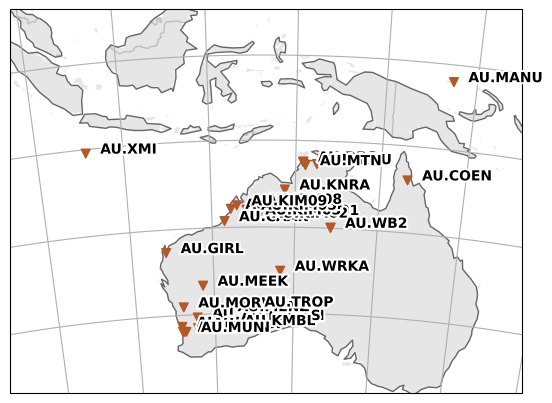

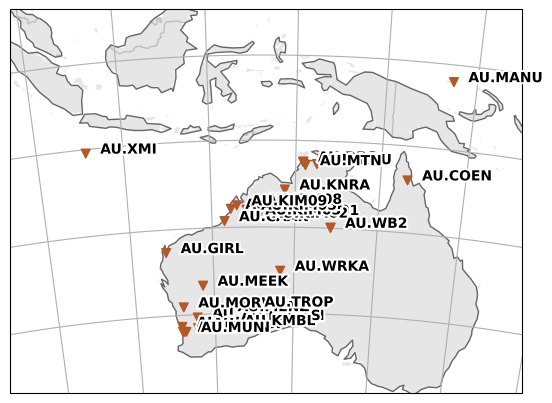

In [7]:
# plot the first stream from the inventory
new_inventory.plot(projection="local", size=40, label=True)


In [8]:
# calculate backazimuth and distance for each station
for network in new_inventory:
    for station in network:
        dist, az, baz = gps2dist_azimuth(hypocentre_lat, hypocentre_lon, station.latitude, station.longitude)
        station.backazimuth = baz
        station.distance    = dist

In [9]:
# for streams with N and E components, rotate to RT
streams = []

for network in new_inventory:
    for station in network:
        try:
            st = client.get_waveforms(network.code, station.code, "*", '??E,??N', starttime_mainshock, endtime_mainshock)
        except:
            print(f"Failed to fetch data for {network.code}.{station.code}")
            continue

        st.rotate(method="NE->RT", back_azimuth=station.backazimuth)

        streams.append(st)


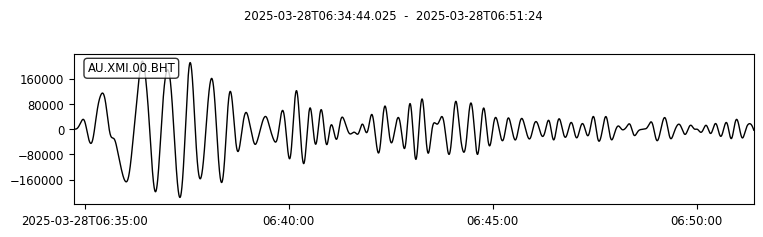

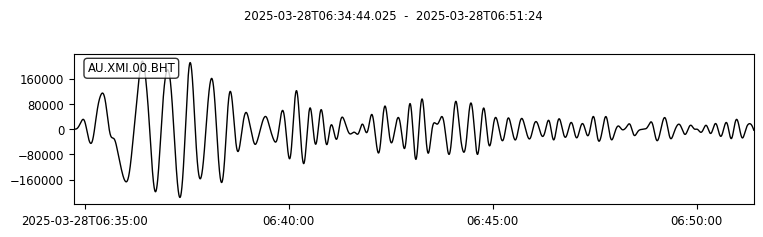

In [10]:
# plot waveform for station MEEK from the inventory
st = client.get_waveforms("AU", "XMI", "*", "*", UTCDateTime("2025-03-28T06:34:44.007766Z"), UTCDateTime("2025-03-28T06:34:44.007766Z") + 1000)
# filter to 25-30s
st.filter("lowpass", freq=1/20)
st.rotate(method="NE->RT", back_azimuth=340)
tr = st.select(component='T')[0]
tr.plot()

# WRKA

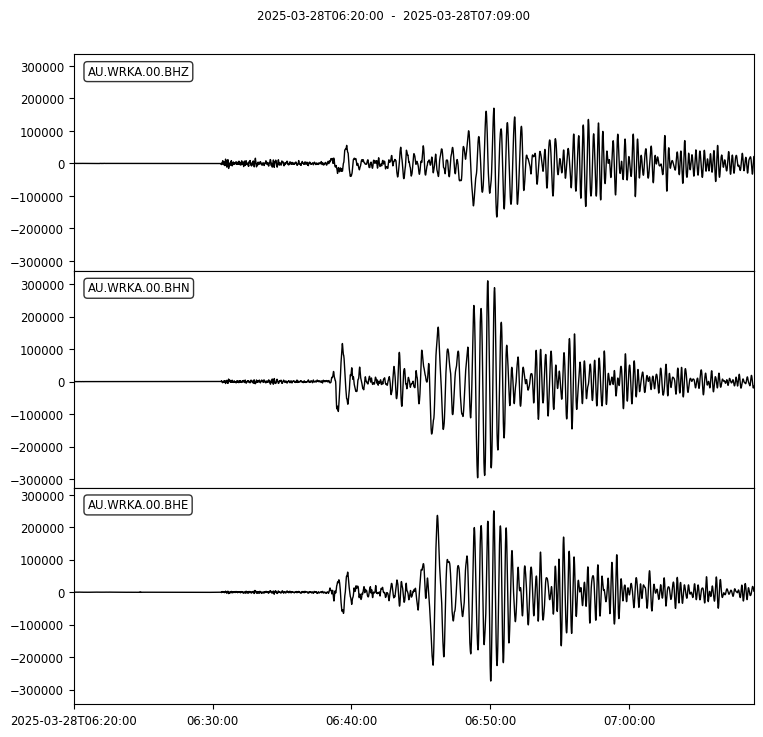

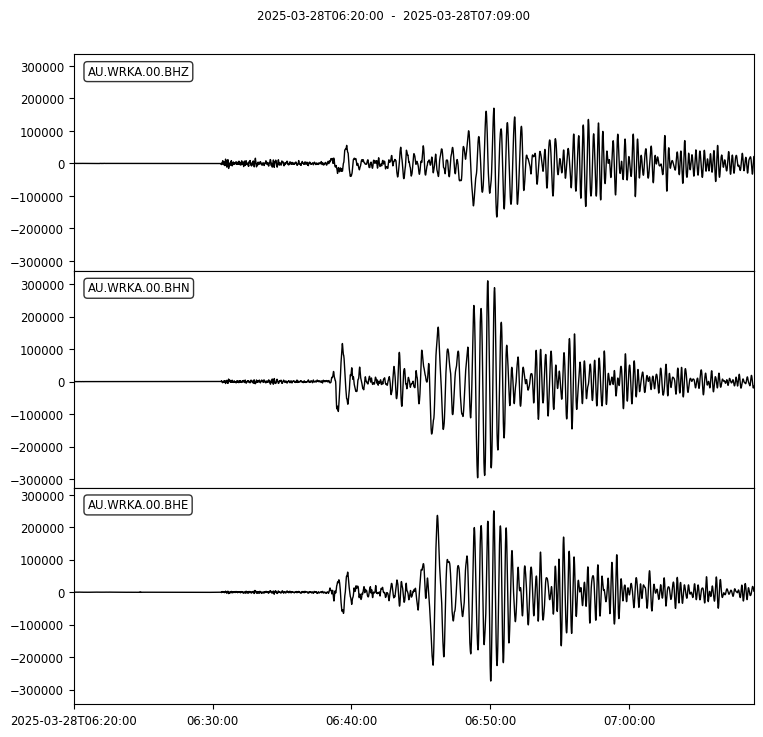

In [11]:
# plot waveform for station MEEK from the inventory
st = client.get_waveforms("AU", "WRKA", "*", "*", UTCDateTime("2025-03-28T06:20:00"), UTCDateTime("2025-03-28T06:44:00")+1500)
# filter to 25-30s
st.plot()

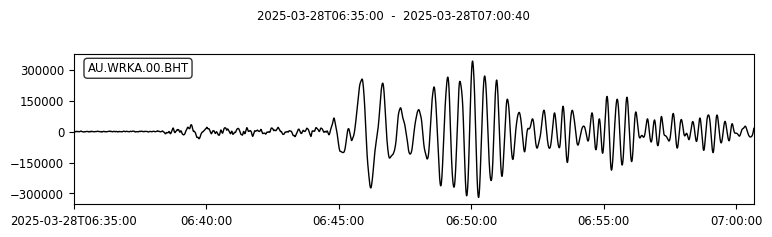

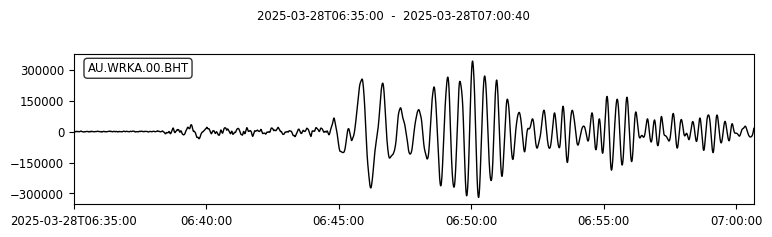

In [12]:
# plot waveform for station MEEK from the inventory
st = client.get_waveforms("AU", "WRKA", "*", "*", UTCDateTime("2025-03-28T06:35:00"), UTCDateTime("2025-03-28T06:44:00")+1000)
# filter to 25-30s
# st.filter("bandpass", freqmin=1, freqmax=30)
st.rotate(method="NE->RT", back_azimuth=340)
tr = st.select(component='T')[0]
tr.plot()

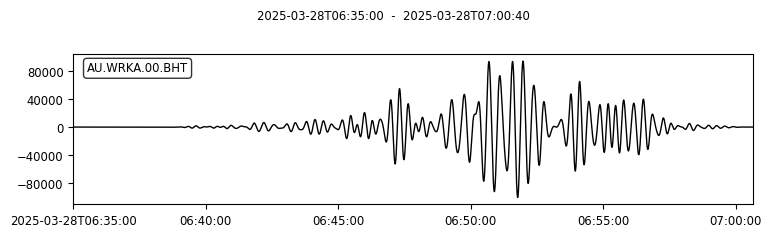

NameError: name 'recursive_sta_lta' is not defined

In [13]:
# plot waveform for station MEEK from the inventory
st = client.get_waveforms("AU", "WRKA", "*", "*", UTCDateTime("2025-03-28T06:35:00"), UTCDateTime("2025-03-28T06:44:00")+1000)
# filter to 25-30s
st.filter("bandpass", freqmin=1/25, freqmax=1/15)
st.rotate(method="NE->RT", back_azimuth=340)
st.taper(max_percentage=0.5)

tr = st.select(component='T')[0]
tr.plot()

cft = recursive_sta_lta(tr.data, int(30*tr.stats.sampling_rate), int(550*tr.stats.sampling_rate))
plot_trigger(tr, cft, 4, 1.9)

# GIRL

In [ ]:
# plot waveform for station MEEK from the inventory
st = client.get_waveforms("AU", "GIRL", "*", "*", UTCDateTime("2025-03-28T06:20:00"), UTCDateTime("2025-03-28T06:44:00")+1000)
# filter to 25-30s
# st.filter("bandpass", freqmin=1, freqmax=30)
st.rotate(method="NE->RT", back_azimuth=340)
tr = st.select(component='T')[0]
tr.plot()

In [ ]:
# plot waveform for station MEEK from the inventory
st = client.get_waveforms("AU", "GIRL", "*", "*", UTCDateTime("2025-03-28T06:20:00"), UTCDateTime("2025-03-28T06:44:00")+1000)
# filter to 25-30s
# st.filter("bandpass", freqmin=1/25, freqmax=1/15)
st.filter("lowpass", freq=1/25)
st.rotate(method="NE->RT", back_azimuth=340)
st.taper(max_percentage=0.5)

tr = st.select(component='T')[0]
tr.plot()

cft = recursive_sta_lta(tr.data, int(100*tr.stats.sampling_rate), int(550*tr.stats.sampling_rate))
plot_trigger(tr, cft, 5, 1.9)

In [ ]:
from obspy.signal.trigger import recursive_sta_lta
from obspy.signal.trigger import plot_trigger

# plot waveform for station MEEK from the inventory
st = client.get_waveforms("AU", "MANU", "*", "*", starttime_mainshock, endtime_mainshock)
# filter to 25-30s
st.filter("bandpass", freqmin=1/25, freqmax=1/15)
st.taper(max_percentage=0.5)
st.rotate(method="NE->RT", back_azimuth=station.backazimuth)
# st.plot()

tr = st.select(component="T")[0]

cft = recursive_sta_lta(tr.data, int(20*tr.stats.sampling_rate), int(115*tr.stats.sampling_rate))
plot_trigger(tr, cft, 1.9, 0.5)

In [ ]:
from obspy.signal.trigger import recursive_sta_lta
from obspy.signal.trigger import plot_trigger

# plot waveform for station MEEK from the inventory
st = client.get_waveforms("AU", "MANU", "*", "*", UTCDateTime("2012-11-11T01:20:28"), UTCDateTime("2012-11-11T01:20:28") + 350)
# filter to 25-30s
st.filter("bandpass", freqmin=1/25, freqmax=1/15)
st.taper(max_percentage=0.5)
st.rotate(method="NE->RT", back_azimuth=station.backazimuth)
# st.plot()

tr = st.select(component="T")[0]

cft = recursive_sta_lta(tr.data, int(20*tr.stats.sampling_rate), int(115*tr.stats.sampling_rate))
plot_trigger(tr, cft, 1.9, 0.5)

# Section plot and mainshock triggers

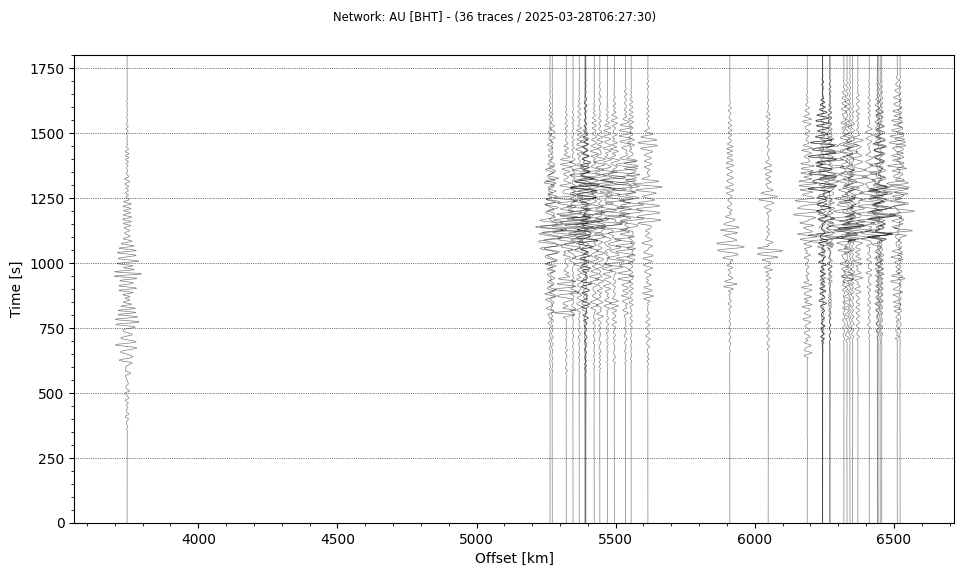

In [120]:
starttime = UTCDateTime("2025-03-28T06:20:00")
endtime = UTCDateTime("2025-03-28T06:44:00") + 1000

# take the transervse traces for all streams and put them in one stream
st = Stream()
for stream in streams:
    # Get T component
    t_stream = stream.select(component="T").copy()
    # t_stream.filter('lowpass', freq=1/20)
    t_stream.filter('bandpass', freqmin=1/30, freqmax=1/15)
    try:
        tr = t_stream[0]
    except IndexError:
        continue

    tr.taper(max_percentage=0.5)
    # get station code
    station_code = t_stream[0].stats.station
    # get station location from inventory
    station = inventory.select(station=station_code)
    # get station location
    lat = station[0][0].latitude
    lon = station[0][0].longitude
    # get distance
    tr.stats.distance = gps2dist_azimuth(hypocentre_lat, hypocentre_lon, lat, lon)[0]

    st += tr

fig = st.plot(type='section', orientation='vertical', color='black', linewidth=0.5, norm=stream)


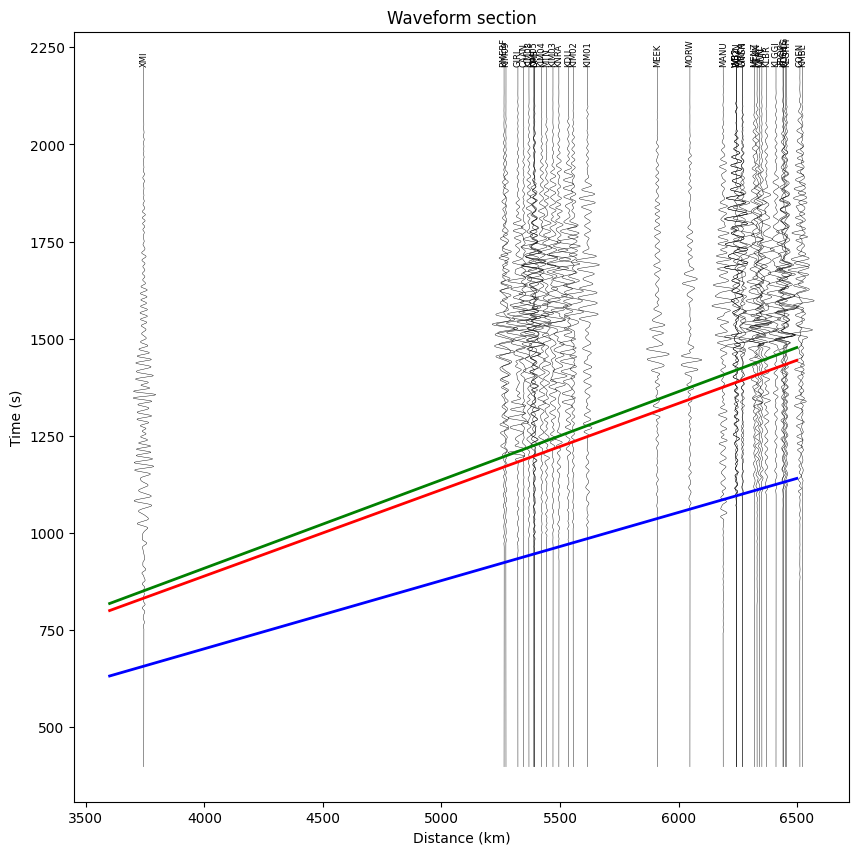

In [121]:
# make section plot with matplotlib
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Waveform section")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Time (s)")

for tr in st:
    # get distance
    dist = tr.stats.distance / 1000
    # get time
    time = tr.times() + (tr.stats.starttime.timestamp - eventtime_mainshock.timestamp)
    # get data
    data = tr.data / (0.02 * np.max(np.abs(tr.data)))

    # plot data
    ax.plot(data + dist, time, color='black', linewidth=0.3)
    ax.text(dist, time[-1], tr.stats.station, fontsize=6, ha='center', va='bottom', rotation='vertical')

    # trigger_time = dist / trigger_speed
    # ax.axhline(trigger_time, color='green', linestyle='--', linewidth=0.5)

# s wave speed
s_wave_speed = 4.5
# p wave speed
p_wave_speed = 5.7
# trigger speed
trigger_speed = 4.4

distance = np.arange(3600, 6500, 1)

# plot s wave speed
ax.plot(distance, distance / s_wave_speed, color='red', linewidth=2)
# plot p wave speed
ax.plot(distance, distance / p_wave_speed, color='blue', linewidth=2)
# plot trigger speed
ax.plot(distance, distance / trigger_speed, color='green', linewidth=2)


# get UTC times of trigger intersection with all traces
trigger_times = dict()
for tr in st:
    # get distance
    dist = tr.stats.distance / 1000
    # get time
    time = tr.times() + (tr.stats.starttime.timestamp - eventtime_mainshock.timestamp)
    # get data
    data = tr.data

    # trigger time based on trigger speed
    trigger_time = dist / trigger_speed
    # get UTC time of trigger
    utc_time = eventtime_mainshock + trigger_time
    # add to dictionary
    trigger_times[tr.stats.station] = utc_time


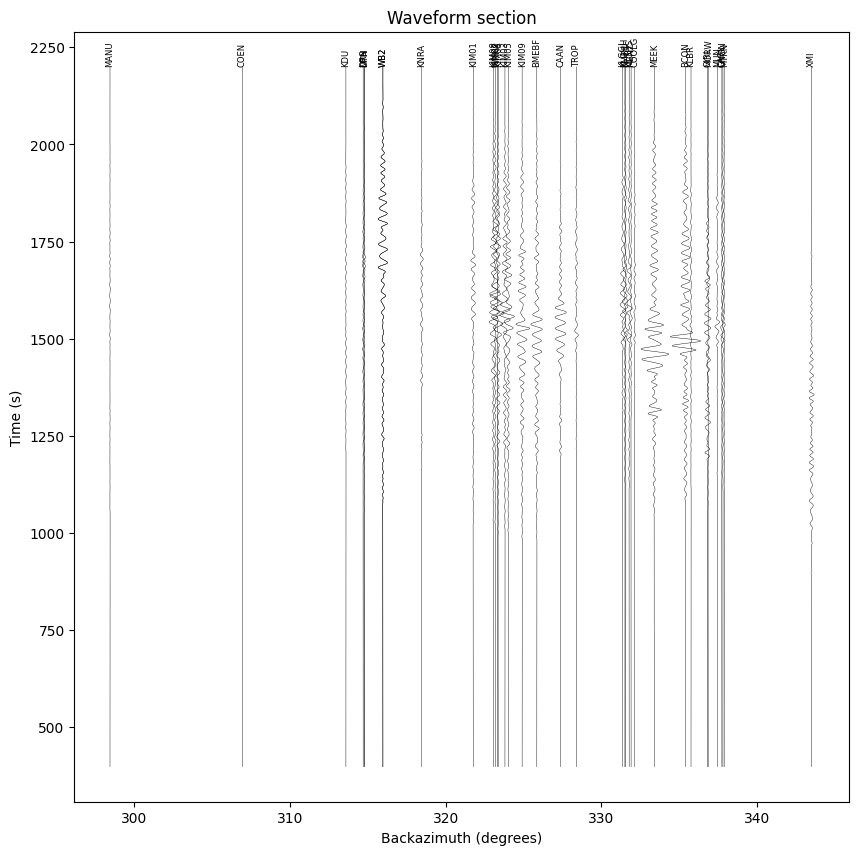

In [122]:
# plot as function of backazimuth
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Waveform section")
ax.set_xlabel("Backazimuth (degrees)")
ax.set_ylabel("Time (s)")

for tr in st:
    # get distance
    backaz = tr.stats.back_azimuth
    # get time
    time = tr.times() + (tr.stats.starttime.timestamp - eventtime_mainshock.timestamp)
    # get data
    data = tr.data / 10e5# (1 * np.max(np.abs(tr.data)))

    # plot data
    ax.plot(data + backaz, time, color='black', linewidth=0.3)
    
    # station name labels
    ax.text(backaz, time[-1], tr.stats.station, fontsize=6, ha='center', va='bottom', rotation='vertical')

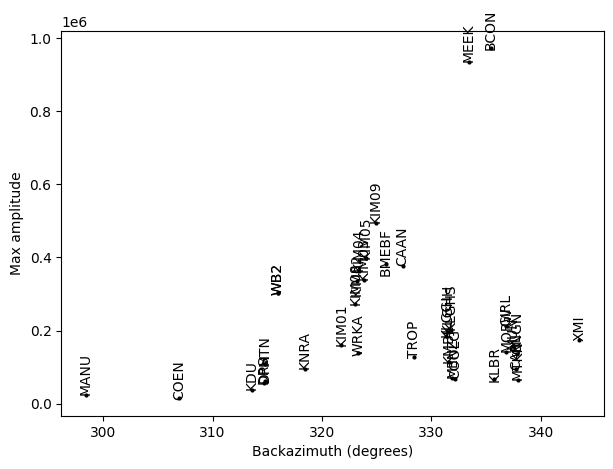

In [126]:
# plot maximum amplitude as function of backazimuth
fig, ax = plt.subplots(figsize=(7,5))
ax.set_ylabel("Max amplitude")
ax.set_xlabel("Backazimuth (degrees)")

mainshock_backazimuth = []
mainshock_maxamp      = []
mainshock_distance    = []

for tr in st:
    # get distance
    backaz = tr.stats.back_azimuth
    # get data
    data = tr.data
    # get max amplitude
    maxamp = np.max(np.abs(data))
    # get distance
    dist = tr.stats.distance / 1000

    mainshock_backazimuth.append(backaz)
    mainshock_maxamp.append(maxamp)
    mainshock_distance.append(dist)

    # plot data
    ax.plot(backaz, maxamp, 'o', color='black', markersize=2)
    
    # station name labels
    ax.text(backaz, np.max(data), tr.stats.station, fontsize=10, ha='center', va='bottom', rotation='vertical')

In [108]:
print(mainshock_distance)

[6244.262297664908, 5264.006141064276, 5346.760089632453, 6342.20623125155, 6512.263027948546, 6450.813747681302, 5391.447004694102, 5393.093594667603, 5322.547921191605, 6270.384556563042, 5535.489356293794, 5615.991399439601, 5555.839612237577, 5470.39038574473, 5422.914812241979, 5389.604353082336, 5369.1014152267135, 5272.165038079505, 6370.617569356098, 6411.298351463239, 6456.3670816266185, 6443.29946416358, 6522.381873410897, 5495.321401560471, 6188.498556552497, 5910.566962867979, 6320.295954168871, 6048.190474355953, 6331.590156231157, 5443.207843670972, 6351.817758046534, 6440.872945544861, 6244.081876469835, 6244.081876469835, 6270.116116651573, 3744.034947262512]


In [19]:
# cut off streams for each station according to the trigger
clipped_streams = []
for stream in streams:
    # Get station code
    station_code = stream[0].stats.station
    # Get cutoff time
    cutoff_time = trigger_times[station_code]
    # Cut off stream
    clipped_stream = stream.select(component="T").copy().trim(starttime=cutoff_time, endtime=cutoff_time + 60*5)
    # Filter stream
    clipped_stream.filter('bandpass', freqmin=1/30, freqmax=1/20)
    # Taper stream
    clipped_stream.taper(max_percentage=0.1)
    # Append to list
    clipped_streams.append(clipped_stream)

# Section plot and preshock triggers

### Preshock parameters


In [109]:
starttime_preshock = UTCDateTime('2012-11-11T01:12:38')
endtime_preshock = UTCDateTime('2012-11-11T01:25:38') + 1000
preshock_lat = 23.005
preshock_lon = 95.885

In [94]:
# for streams with N and E components, rotate to RT
streams_preshock = []

for network in new_inventory:
    for station in network:
        try:
            st = client.get_waveforms(network.code, station.code, "*", '??E,??N', starttime_preshock, endtime_preshock)
        except:
            print(f"Failed to fetch data for {network.code}.{station.code}")
            continue

        st.rotate(method="NE->RT", back_azimuth=station.backazimuth)

        streams_preshock.append(st)


Failed to fetch data for AU.BCON
Failed to fetch data for AU.BMEBF
Failed to fetch data for AU.CAAN
Failed to fetch data for AU.CARL
Failed to fetch data for AU.COOLG
Failed to fetch data for AU.DPH
Failed to fetch data for AU.DRS
Failed to fetch data for AU.GNGN
Failed to fetch data for AU.KIM01
Failed to fetch data for AU.KIM02
Failed to fetch data for AU.KIM03
Failed to fetch data for AU.KIM04
Failed to fetch data for AU.KIM05
Failed to fetch data for AU.KIM08
Failed to fetch data for AU.KIM09
Failed to fetch data for AU.KLGGI
Failed to fetch data for AU.KLGHH
Failed to fetch data for AU.KLGHS
Failed to fetch data for AU.MENZ
Failed to fetch data for AU.MTKN
Failed to fetch data for AU.TROP


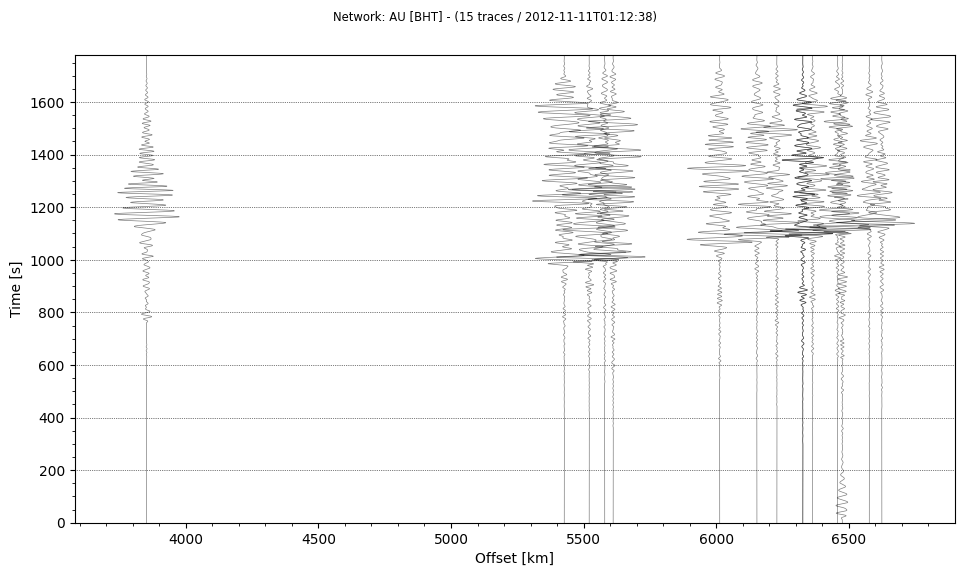

In [110]:
# take the transervse traces for all streams and put them in one stream
st = Stream()
for stream in streams_preshock:
    # Get T component
    t_stream = stream.select(component="T").copy()
    # t_stream.filter('lowpass', freq=1/20)
    t_stream.filter('bandpass', freqmin=1/30, freqmax=1/15)
    try:
        tr = t_stream[0]
    except IndexError:
        continue

    tr.taper(max_percentage=0.5)
    # get station code
    station_code = t_stream[0].stats.station
    # get station location from inventory
    station = inventory.select(station=station_code)
    # get station location
    lat = station[0][0].latitude
    lon = station[0][0].longitude
    # get distance
    tr.stats.distance = gps2dist_azimuth(preshock_lat, preshock_lon, lat, lon)[0]

    st += tr

fig = st.plot(type='section', orientation='vertical', color='black', linewidth=0.5, norm=stream)


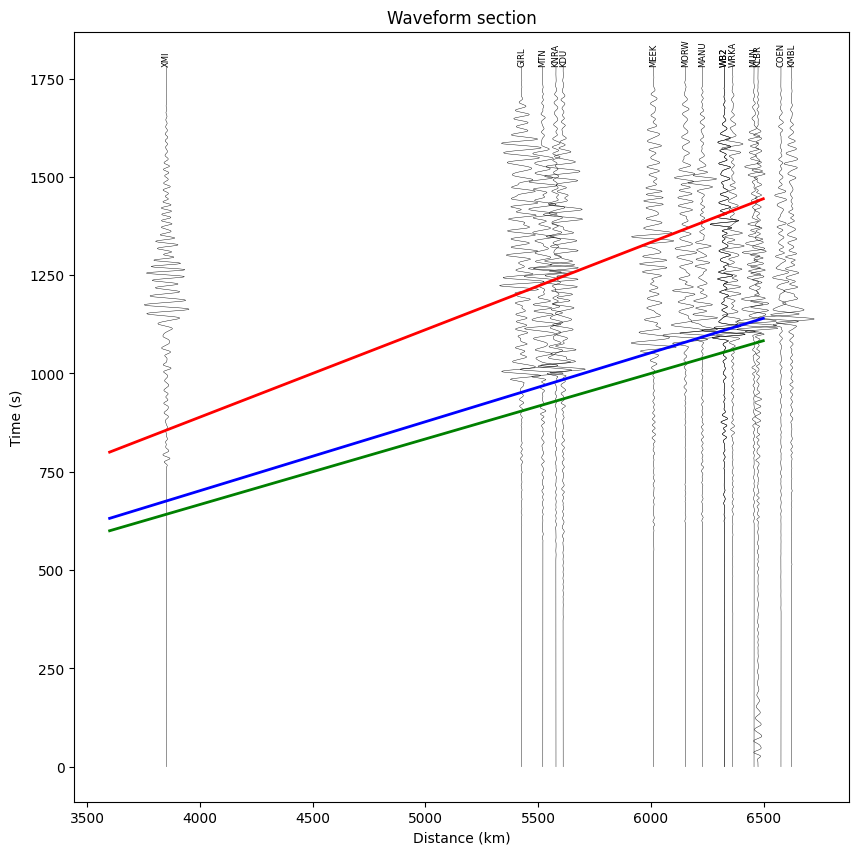

In [111]:
# make section plot with matplotlib
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Waveform section")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Time (s)")

for tr in st:
    # get distance
    dist = tr.stats.distance / 1000
    # get time
    time = tr.times() # + (tr.stats.starttime.timestamp - eventtime_mainshock.timestamp)
    # get data
    data = tr.data / (0.01 * np.max(np.abs(tr.data)))

    # plot data
    ax.plot(data + dist, time, color='black', linewidth=0.3)
    ax.text(dist, time[-1], tr.stats.station, fontsize=6, ha='center', va='bottom', rotation='vertical')

    # trigger_time = dist / trigger_speed
    # ax.axhline(trigger_time, color='green', linestyle='--', linewidth=0.5)

# s wave speed
s_wave_speed = 4.5
# p wave speed
p_wave_speed = 5.7
# trigger speed
trigger_speed = 6

distance = np.arange(3600, 6500, 1)

# plot s wave speed
ax.plot(distance, distance / s_wave_speed, color='red', linewidth=2)
# plot p wave speed
ax.plot(distance, distance / p_wave_speed, color='blue', linewidth=2)
# plot trigger speed
ax.plot(distance, distance / trigger_speed, color='green', linewidth=2)


# get UTC times of trigger intersection with all traces
trigger_times_preshock = dict()
for tr in st:
    # get distance
    dist = tr.stats.distance / 1000
    # get time
    time = tr.times() # + (tr.stats.starttime.timestamp - eventtime_mainshock.timestamp)
    # get data
    data = tr.data

    # trigger time based on trigger speed
    trigger_time = dist / trigger_speed
    # get UTC time of trigger
    utc_time = starttime_preshock + trigger_time
    # add to dictionary
    trigger_times_preshock[tr.stats.station] = utc_time


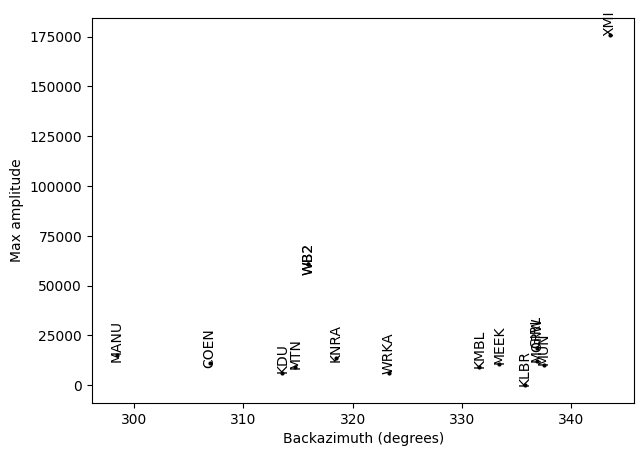

In [112]:
# plot maximum amplitude as function of backazimuth
fig, ax = plt.subplots(figsize=(7,5))
ax.set_ylabel("Max amplitude")
ax.set_xlabel("Backazimuth (degrees)")

preshock_backazimuth = []
preshock_maxamp      = []
preshock_distance    = []

for tr in st:
    # get distance
    backaz = tr.stats.back_azimuth
    # get data
    data = tr.data
    # get max amplitude
    maxamp = np.max(np.abs(data))
    # get distance
    dist = tr.stats.distance / 1000

    preshock_backazimuth.append(backaz)
    preshock_maxamp.append(maxamp)
    preshock_distance.append(dist)

    # plot data
    ax.plot(backaz, maxamp, 'o', color='black', markersize=2)
    
    # station name labels
    ax.text(backaz, np.max(data), tr.stats.station, fontsize=10, ha='center', va='bottom', rotation='vertical')

In [113]:
print(preshock_distance)

[6577.42951924556, 5427.110055388741, 5611.51106071879, 6475.748507178206, 6624.730762482561, 5579.6141452596985, 6228.842437413064, 6013.276383437887, 6153.604933650071, 5521.142686733162, 6457.979054362676, 6326.623822043712, 6326.623822043712, 6363.492421266677, 3851.947118249188]


In [78]:
# cut off streams for each station according to the trigger
clipped_streams_preshock = []
for stream in streams_preshock:
    # Get station code
    station_code = stream[0].stats.station
    # Get cutoff time
    cutoff_time = trigger_times_preshock[station_code]
    print(cutoff_time)
    # Cut off stream
    clipped_stream = stream.select(component="T").copy().trim(starttime=cutoff_time, endtime=cutoff_time + 60*5)
    # Filter stream
    clipped_stream.filter('bandpass', freqmin=1/30, freqmax=1/20)
    # Taper stream
    clipped_stream.taper(max_percentage=0.1)
    # Append to list
    clipped_streams_preshock.append(clipped_stream)

2012-11-11T01:30:54.238253Z
2012-11-11T01:27:42.518343Z
2012-11-11T01:28:13.251843Z
2012-11-11T01:30:37.291418Z
2012-11-11T01:31:02.121794Z
2012-11-11T01:28:07.935691Z
2012-11-11T01:29:56.140406Z
2012-11-11T01:29:20.212731Z
2012-11-11T01:29:43.600822Z
2012-11-11T01:27:58.190448Z
2012-11-11T01:30:34.329842Z
2012-11-11T01:30:12.437304Z
2012-11-11T01:30:12.437304Z
2012-11-11T01:30:18.582070Z
2012-11-11T01:23:19.991186Z


# Backazimuth amplitude plots

(array([ 1,  2,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17, 23, 29, 35]),) [array([ 1,  2,  5,  9, 14])]


TypeError: list indices must be integers or slices, not tuple

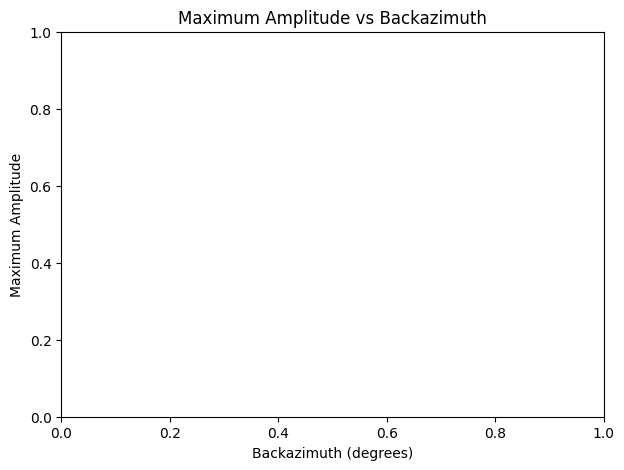

In [118]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Maximum Amplitude vs Backazimuth')
ax.set_xlabel('Backazimuth (degrees)')
ax.set_ylabel('Maximum Amplitude')

# # remove maximum amplitude from preshock
mainshock_maxamp = np.array(mainshock_maxamp)
mainshock_backazimuth = np.array(mainshock_backazimuth)
preshock_maxmap = np.array(preshock_maxamp)
preshock_backazimuth = np.array(preshock_backazimuth)
mainshock_distance = np.array(mainshock_distance)
preshock_distance = np.array(preshock_distance)
# # remove np.max(preshock_maxmap) from preshock_maxmap
# preshock_backazimuth = preshock_backazimuth[preshock_maxmap != np.max(preshock_maxmap)]
# preshock_maxamp = preshock_maxmap[preshock_maxmap != np.max(preshock_maxmap)]

# for i in range(2):
#     mainshock_backazimuth = mainshock_backazimuth[mainshock_maxamp != np.max(mainshock_maxamp)]
#     mainshock_maxamp = mainshock_maxamp[mainshock_maxamp != np.max(mainshock_maxamp)]

# get indices where distance is less than 5800
mainshock_indices = np.where(mainshock_distance < 5800)
preshock_indices = np.where(preshock_distance < 5800)

print(mainshock_indices, preshock_indices)

# keep only those indices
mainshock_backazimuth_filter = mainshock_backazimuth[mainshock_indices]
mainshock_maxamp_filter  = mainshock_maxamp[mainshock_indices]
mainshock_distance_filter  = mainshock_distance[mainshock_indices]
preshock_backazimuth_filter  = preshock_backazimuth[preshock_indices]
preshock_maxamp_filter  = preshock_maxamp[preshock_indices]
preshock_distance_filter  = preshock_distance[preshock_indices]

# Plot maximum amplitude as function of backazimuth for mainshock
ax.plot(mainshock_backazimuth_filter, mainshock_maxamp_filter  / np.max(mainshock_maxamp_filter ), 'o', color='black', markersize=5, label='2025-03-28 Mw 7.7')

# Plot maximum amplitude as function of backazimuth for preshock
ax.plot(preshock_backazimuth_filter , preshock_maxamp_filter  / np.max(preshock_maxamp_filter ), 'x', color='black', markersize=5, label='2012-11-11 Mw 6.8')

# Add legend
ax.legend(loc='upper left')
# show
plt.show()


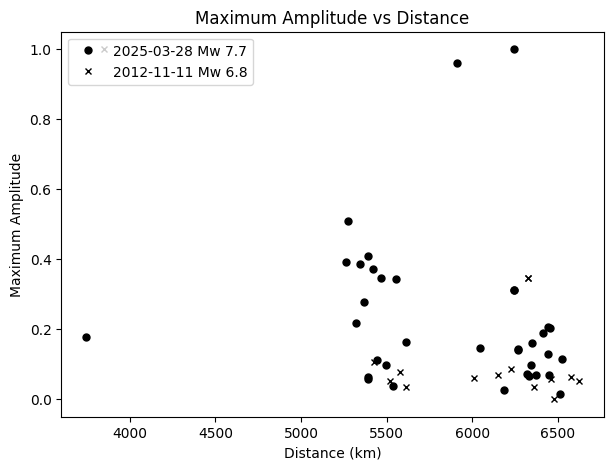

In [115]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Maximum Amplitude vs Distance')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Maximum Amplitude')

# # remove maximum amplitude from preshock
# mainshock_maxamp = np.array(mainshock_maxamp)
# mainshock_backazimuth = np.array(mainshock_backazimuth)
# preshock_maxmap = np.array(preshock_maxamp)
# preshock_backazimuth = np.array(preshock_backazimuth)
# # remove np.max(preshock_maxmap) from preshock_maxmap
# preshock_backazimuth = preshock_backazimuth[preshock_maxmap != np.max(preshock_maxmap)]
# preshock_maxamp = preshock_maxmap[preshock_maxmap != np.max(preshock_maxmap)]

# for i in range(2):
#     mainshock_backazimuth = mainshock_backazimuth[mainshock_maxamp != np.max(mainshock_maxamp)]
#     mainshock_maxamp = mainshock_maxamp[mainshock_maxamp != np.max(mainshock_maxamp)]

# Plot maximum amplitude as function of backazimuth for mainshock
ax.plot(mainshock_distance, mainshock_maxamp / np.max(mainshock_maxamp), 'o', color='black', markersize=5, label='2025-03-28 Mw 7.7')

# Plot maximum amplitude as function of backazimuth for preshock
ax.plot(preshock_distance, preshock_maxamp / np.max(preshock_maxamp), 'x', color='black', markersize=5, label='2012-11-11 Mw 6.8')

# Add legend
ax.legend(loc='upper left')
# show
plt.show()


# Cross correlation

#### Clean lists and trim

In [80]:
mainshock = clipped_streams.copy()
preshock = clipped_streams_preshock.copy()

# find stations in common between trigger_times and trigger_times_preshock
common_stations = set(trigger_times.keys()).intersection(set(trigger_times_preshock.keys()))

# filter streams to only include common stations
mainshock = [stream for stream in mainshock if stream[0].stats.station in common_stations]
preshock = [stream for stream in preshock if stream[0].stats.station in common_stations]

# sort streams by backazimuth
mainshock.sort(key=lambda x: x[0].stats.back_azimuth)
preshock.sort(key=lambda x: x[0].stats.back_azimuth)

# moment ratio
moment_ratio = 4.634e20 /2.287e19

# scale preshock by moment ratio
for stream in preshock:
    for tr in stream:
        tr.data = tr.data * moment_ratio

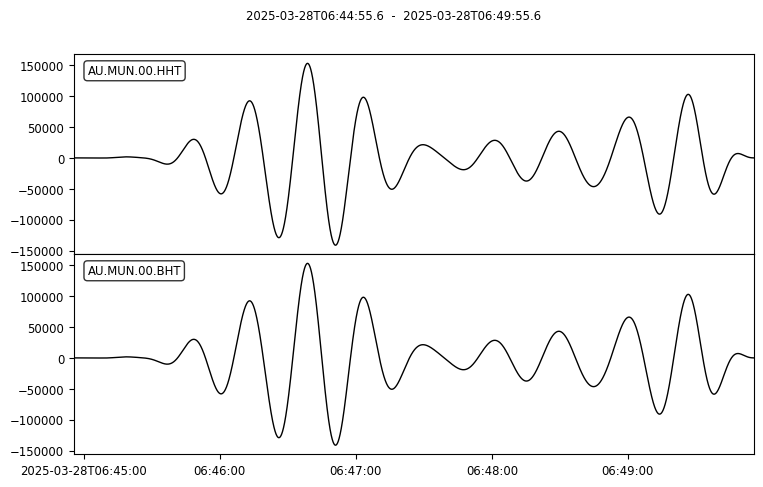

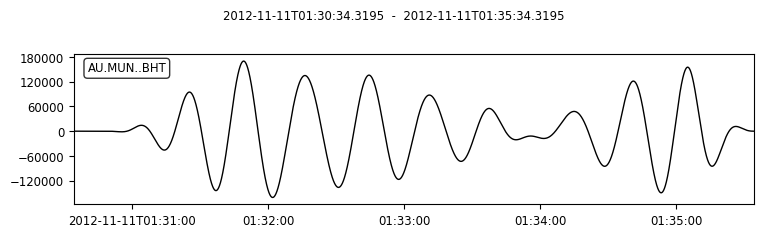

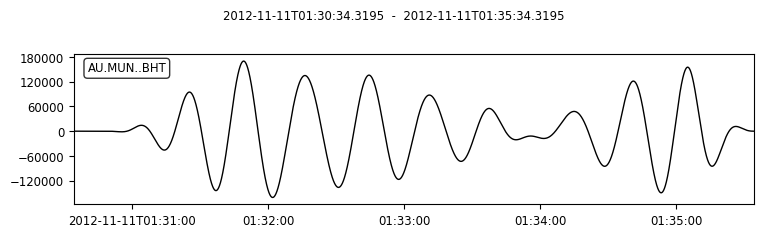

In [81]:
index = 13
mainshock[index].plot()
preshock[index].plot()

### Cross correlation function

In [82]:
xcorr_values = []
backazimuth  = []
max_amp      = []

for mainwave, prewave in zip(mainshock, preshock):
    # get station code
    station_code = mainwave[0].stats.station
    # get sampling rate
    sampling_rate = mainwave[0].stats.sampling_rate
    # set shift to be 2 minutes
    shift = sampling_rate * 60 * 5
    
    # cross correlate
    cc = correlate(mainwave[0].data, prewave[0].data, shift=20000, method='fft')

    # get max correlation
    shift, value = xcorr_max(cc)

    print(station_code, value, shift)
    xcorr_values.append(value)
    backazimuth.append(mainwave[0].stats.back_azimuth)
    max_amp.append(np.max(mainwave[0].data))

MANU -0.6468383590977913 5092
COEN 0.664617551040314 6116
KDU 0.817440477557557 -356
MTN 0.593284781533423 -335
WB2 0.4987182318991262 -32
WB2 0.49871701239791594 -32
KNRA 0.7460381429673886 2215
WRKA 0.5989862885352549 2928
KMBL 0.6148568329165517 3235
MEEK 0.628727861332577 990
KLBR 0.7865177350233629 939
GIRL 0.7788155578879801 -647
MORW 0.6445439457781491 -590
MUN -0.845539659221761 535
XMI -0.6890961725757719 375


Text(0, 0.5, 'Cross correlation value')

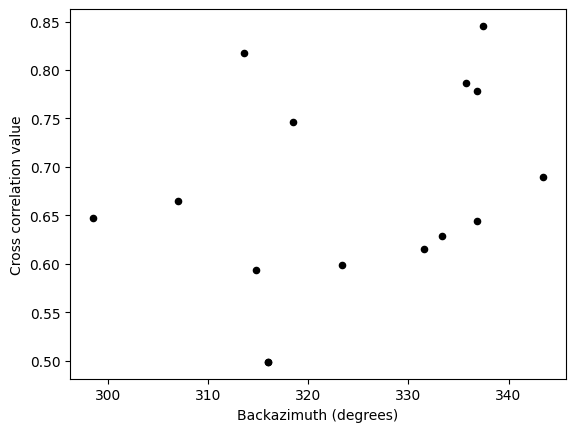

In [83]:
plt.scatter(backazimuth, np.abs(xcorr_values), color='black', s=20)
plt.xlabel('Backazimuth (degrees)')
plt.ylabel('Cross correlation value')
# plt.scatter(backazimuth, max_amp / np.max(max_amp), color='red')